# Jour 1 — Lumina & Co : nettoyage et EDA du CRM

**Question du CMO :** *"On a des dizaines de milliers de clients dans notre CRM
mais on leur envoie les mêmes emails à tout le monde. On ne sait même pas si
ce sont des acheteurs réguliers ou des gens qui ont commandé une seule fois il
y a deux ans. C'est un problème ?"*

Pour répondre à cette question au Jour 2 (segmentation RFM), il faut d'abord
un socle de données fiable. Ce notebook se limite volontairement à deux
choses : **comprendre** ce que contient l'export CRM (`customers.csv`,
`transactions.csv`), et le **nettoyer**. Pas de segmentation, pas
d'attribution, pas de modélisation ici — ce sera pour les jours suivants.

Deux fichiers ne sont pas utilisés aujourd'hui : `touchpoints.csv` et
`campaigns.csv` (Jours 3-4).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../outputs/figures")
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Étape 1 — Chargement et constat

Aucun nettoyage dans cette section. On charge les fichiers tels quels et on
décrit ce qu'on observe : volumétrie, période, valeurs manquantes, types,
doublons. L'objectif est de regarder les données sans a priori avant de
décider quoi que ce soit.

In [2]:
customers = pd.read_csv(RAW / "customers.csv")
transactions = pd.read_csv(RAW / "transactions.csv")

print(f"customers.csv     : {customers.shape[0]:,} lignes x {customers.shape[1]} colonnes")
print(f"transactions.csv  : {transactions.shape[0]:,} lignes x {transactions.shape[1]} colonnes")

customers.csv     : 50,295 lignes x 13 colonnes
transactions.csv  : 1,613,433 lignes x 9 colonnes


In [3]:
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
print("Période couverte par transactions.csv :")
print(f"  du {transactions['invoice_date'].min().date()} au {transactions['invoice_date'].max().date()}")

Période couverte par transactions.csv :


  du 2022-01-07 au 2026-06-30


**Volumétrie :** 50 295 clients et 1 613 433 transactions, sur une période de
2022-01-07 à 2026-06-30, soit un peu plus de 4 ans et demi.

In [4]:
def missing_report(df, name):
    rep = pd.DataFrame({
        "type": df.dtypes,
        "n_manquants": df.isna().sum(),
        "%_manquants": (df.isna().mean() * 100).round(2),
    })
    print(f"--- {name} ---")
    return rep

missing_report(customers, "customers.csv")

--- customers.csv ---


,type,n_manquants,%_manquants
customer_id,int64,0,0.00
country,str,0,0.00
first_purchase,str,0,0.00
last_purchase,str,0,0.00
n_orders,int64,0,0.00
total_spent,float64,0,0.00
avg_basket,float64,0,0.00
recency_days,int64,0,0.00
tenure_days,int64,0,0.00
declared_preference,str,31108,61.85


In [5]:
missing_report(transactions, "transactions.csv")

--- transactions.csv ---


,type,n_manquants,%_manquants
invoice_id,str,0,0.00
customer_id,float64,367328,22.77
product_code,str,0,0.00
product_name,str,2241,0.14
category,str,0,0.00
quantity,int64,0,0.00
unit_price,float64,0,0.00
invoice_date,datetime64[us],0,0.00
country,str,0,0.00


**Valeurs manquantes :** `customers.csv` n'a aucune valeur manquante sur les
colonnes numériques et transactionnelles, mais les 4 colonnes zero-party
(`declared_preference`, `age_bracket`, `life_stage`, `urban_density`) sont
très incomplètes (19,8 % à 42,7 % de remplissage — voir Étape 4). Dans
`transactions.csv`, seule la colonne `customer_id` a des manquants, mais ils
sont massifs : 22,8 % des lignes.

**Types attendus vs observés :** `customer_id` est chargé en `float64` dans
`transactions.csv` (à cause des `NaN`, qui interdisent le typage entier natif
de pandas), alors qu'il s'agit d'un identifiant. `invoice_date` est une chaîne
de caractères à l'import, à convertir en `datetime` (fait ci-dessus). Le reste
est cohérent avec ce qu'on attend.

In [6]:
n_dup_transactions = transactions.duplicated().sum()
n_dup_customers = customers["customer_id"].duplicated().sum()
print(f"Lignes strictement dupliquées dans transactions.csv : {n_dup_transactions:,}")
print(f"customer_id dupliqués dans customers.csv             : {n_dup_customers:,}")

Lignes strictement dupliquées dans transactions.csv : 445
customer_id dupliqués dans customers.csv             : 0


**Doublons :** 445 lignes strictement identiques dans `transactions.csv`
(même facture, même produit, même quantité, même prix, même date). Aucun
`customer_id` dupliqué dans `customers.csv` — c'est bien une ligne par client.

## Étape 2 — Data quality report : 5 observations clés

Avant toute transformation. Chaque observation est chiffrée et reliée à son
impact sur la segmentation du Jour 2.

**1. Près d'un quart des transactions ne peuvent être rattachées à aucun
client.** 367 328 lignes (22,8 %) de `transactions.csv` ont un
`customer_id` manquant, pour un total de 11,5 M€ de chiffre d'affaires brut.
*Impact :* ce volume ne pourra pas alimenter la segmentation RFM par client —
il faudra le traiter à part dans les analyses globales (CA, saisonnalité) et
l'exclure des analyses par client.

**2. Les agrégats de `customers.csv` ne correspondent pas au grand livre
transactionnel.** `total_spent` est interne cohérent avec `avg_basket`
(`avg_basket = total_spent / n_orders` exactement), mais la somme de
`total_spent` sur toute la base (169,7 M€) est plus de 4 fois supérieure au
chiffre d'affaires recalculé depuis `transactions.csv` (~40 M€, hors avoirs,
frais et lignes sans client). Client par client, le ratio médian est d'environ
7. `n_orders`, en revanche, est globalement cohérent avec le nombre de
factures observées dans `transactions.csv`. *Impact :* on ne peut pas faire
confiance à `total_spent` ni à `avg_basket` de `customers.csv` pour la
composante Monétaire du RFM — il faudra la recalculer depuis
`transactions.csv`, ce que fait ce notebook (Étape 3).

**3. La base est fortement biaisée géographiquement.** 45 904 clients sur
50 295 (91,3 %) sont en France ; le deuxième pays, l'Allemagne, n'en compte
que 918 (1,8 %). *Impact :* toute segmentation ou tout comportement moyen
calculé sur l'ensemble de la base reflétera essentiellement le comportement
français. Les segments internationaux seront statistiquement fragiles
(quelques centaines d'individus) et ne doivent pas être généralisés.

**4. Le chiffre d'affaires brut est pollué par des lignes qui ne sont pas des
ventes.** 34 691 lignes ont une quantité négative (dont 19 494 rattachées à
8 292 factures d'avoir commençant par "C" — des retours), 10 897 lignes ont un
prix unitaire à 0 € et 177 un prix négatif, et 7 465 lignes appartiennent à la
catégorie "Frais" (frais de port, ajustements manuels, remises, dons,
échantillons). *Impact :* sans traitement, le chiffre d'affaires, le panier
moyen et la répartition par catégorie seraient surestimés ou faussés par des
lignes qui ne représentent pas des achats de produits.

**5. Les données zero-party sont rares et ne signalent pas la valeur
client.** Les taux de remplissage vont de 19,8 % (`urban_density`) à 42,7 %
(`age_bracket`). Le `total_spent` moyen est quasiment identique entre clients
ayant renseigné une préférence et les autres (écart < 1 %). *Impact :* ces
colonnes ne peuvent pas servir seules à prioriser les clients à forte valeur ;
elles pourront enrichir le RFM du Jour 2 mais pas le remplacer. À noter
également une incohérence mineure de dates : la marque est présentée comme
fondée il y a 3 ans (donc en 2023), mais 1 502 transactions sont datées de
2022 — à signaler au CMO sans bloquer l'analyse.

## Étape 3 — Nettoyage

Pour chaque traitement : ce qu'on fausse si on garde, ce qu'on perd si on
supprime, et pourquoi ce choix plutôt qu'un autre — **avant** le code.

In [7]:
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]

### 3.1 — `customer_id` manquants (367 328 lignes, 22,8 %)

- **Si je garde tel quel :** je ne peux pas les rattacher à un profil client
  — impossible de les inclure dans un calcul de récence, fréquence ou montant
  par client sans inventer un rattachement.
- **Si je supprime entièrement :** je perds 22,8 % du volume de transactions
  et environ 11,5 M€ de chiffre d'affaires brut réel — la vue globale du CA
  (mensuel, par catégorie) serait sous-estimée.
- **Décision :** je garde deux vues. `transactions` (tout, y compris sans
  `customer_id`) sert aux analyses globales (CA mensuel, catégories). Une vue
  filtrée `transactions_customer` (avec `customer_id` renseigné) sert à toute
  analyse par client, dont le RFM du Jour 2. Je n'impute jamais un
  `customer_id` inventé : ce serait fabriquer un comportement client qui
  n'existe pas.

In [8]:
transactions_customer = transactions[transactions["customer_id"].notna()].copy()
transactions_customer["customer_id"] = transactions_customer["customer_id"].astype(int)
print(f"transactions_customer : {len(transactions_customer):,} lignes ({len(transactions_customer)/len(transactions):.1%} du total)")

transactions_customer : 1,246,105 lignes (77.2% du total)


### 3.2 — Avoirs / retours (quantités négatives, factures "C")

- **Si je garde sans distinction :** une ligne d'avoir (quantité négative)
  mélangée à des ventes positives fausse le panier moyen si je ne fais pas
  attention au signe, et fausse le nombre de commandes si je compte les
  factures d'avoir comme des achats.
- **Si je supprime entièrement :** je perds la visibilité sur le taux de
  retour, qui peut être un signal de churn ou d'insatisfaction produit.
- **Décision :** je garde les avoirs dans le jeu de données (indicateur
  `is_return`, quantité négative / facture commençant par "C") pour pouvoir
  mesurer le taux de retour séparément, mais je les exclue de tous les
  calculs de chiffre d'affaires, de nombre de commandes et de panier moyen de
  ce notebook — ces indicateurs visent le volume de vente de produits, pas le
  solde comptable net. Le taux de retour est un signal à part (satisfaction,
  churn), pas une composante du CA marketing.

*Note : 6 867 de ces 34 691 lignes n'ont pas de `customer_id` et ont déjà été
écartées à l'étape 3.1. Le comptage ci-dessous porte donc sur
`transactions_customer`, le sous-ensemble restant.*

In [9]:
transactions_customer["is_return"] = (
    transactions_customer["quantity"] < 0
) | transactions_customer["invoice_id"].astype(str).str.startswith("C")

n_returns = transactions_customer["is_return"].sum()
print(f"Lignes identifiées comme avoirs/retours (dans transactions_customer) : {n_returns:,} ({n_returns/len(transactions_customer):.1%})")

Lignes identifiées comme avoirs/retours (dans transactions_customer) : 27,824 (2.2%)


### 3.3 — Prix unitaires à 0 € et prix négatifs

- **Si je garde sans distinction :** les prix négatifs (177 lignes, toutes
  dans la catégorie "Frais") sont des ajustements comptables, pas des ventes
  — les inclure dans un chiffre d'affaires produit n'a pas de sens. Les prix à
  0 € (10 897 lignes) sont répartis sur toutes les catégories produit, pas
  seulement "Frais" : ce sont vraisemblablement des échantillons ou cadeaux
  offerts, pas une erreur de saisie généralisée.
- **Si je supprime toutes ces lignes :** je perds la visibilité sur les
  échantillons/cadeaux offerts (utile pour mesurer l'effet d'une politique de
  gratuité), et je fausserais le compte de commandes si un panier entier
  n'avait que des lignes à 0 €.
- **Décision :** les prix négatifs sont exclus de tout calcul de chiffre
  d'affaires (`unit_price >= 0`). Les prix à 0 € sont conservés dans les
  volumes (quantité, nombre de commandes) mais leur contribution au chiffre
  d'affaires est naturellement nulle — aucun traitement spécial requis au-delà
  du filtre sur les prix négatifs.

*Note : ces 177 et 10 897 lignes sont comptées sur le fichier brut complet.
Une bonne partie n'a pas de `customer_id` (respectivement 3 et 7 262 lignes) et
a déjà été écartée à l'étape 3.1 — le comptage ci-dessous porte sur
`transactions_customer`.*

In [10]:
n_neg_price = (transactions_customer["unit_price"] < 0).sum()
n_zero_price = (transactions_customer["unit_price"] == 0).sum()
print(f"Dans transactions_customer -> Prix négatifs : {n_neg_price:,} | Prix à 0 € : {n_zero_price:,}")

transactions_customer = transactions_customer[transactions_customer["unit_price"] >= 0].copy()

Dans transactions_customer -> Prix négatifs : 174 | Prix à 0 € : 3,635


### 3.4 — Codes non-produits / catégorie "Frais"

- **Si je garde ces lignes dans le CA produit :** frais de port, frais
  bancaires, ajustements manuels, remises commerciales et dons caritatifs
  viendraient polluer le chiffre d'affaires par catégorie et le panier moyen
  produit — 7 465 lignes au total, avec des codes comme `POST`, `DOT`, `M`,
  `BANK CHARGES`, `ADJUST`, `AMAZONFEE`, `GIFT`, `CRUK`, `PADS`.
- **Si je supprime la catégorie entière sans la regarder :** je perds la
  visibilité sur les frais de port facturés ou les remises accordées, qui
  peuvent intéresser la finance (hors périmètre marketing de ce cours).
- **Décision :** j'exclue la catégorie "Frais" de toutes les analyses de CA
  produit, panier moyen et fréquence d'achat, qui portent uniquement sur les
  ventes de produits. Un indicateur `is_fee` est conservé pour ne pas perdre
  l'information si besoin plus tard.

*Note : sur les 7 465 lignes "Frais" du fichier brut, 2 545 n'ont pas de
`customer_id` (déjà écartées) et 174 avaient un prix négatif (déjà écartées à
l'étape 3.3) — il en reste 4 746 dans `transactions_customer` à ce stade.*

In [11]:
transactions_customer["is_fee"] = transactions_customer["category"] == "Frais"
n_fee = transactions_customer["is_fee"].sum()
print(f"Lignes 'Frais' restantes dans transactions_customer : {n_fee:,} ({n_fee/len(transactions_customer):.1%})")

Lignes 'Frais' restantes dans transactions_customer : 4,746 (0.4%)


### 3.5 — Doublons stricts (445 lignes sur le fichier brut)

- **Si je garde :** chaque ligne dupliquée compte deux fois la même vente —
  double comptage de quantité et de chiffre d'affaires.
- **Si je supprime :** aucune perte d'information réelle — une ligne
  strictement identique (même facture, produit, quantité, prix, date) sur un
  export CRM est une duplication technique, pas deux achats distincts.
- **Décision :** suppression des doublons stricts, à ce stade du pipeline
  (après les filtres précédents, une partie des 445 doublons bruts sont déjà
  sortis de `transactions_customer`).

In [12]:
before = len(transactions_customer)
transactions_customer = transactions_customer.drop_duplicates()
print(f"Doublons supprimés : {before - len(transactions_customer):,}")

Doublons supprimés : 254


### Recalcul des agrégats client et comparaison à `customers.csv`

On calcule maintenant, à partir de `transactions_customer` nettoyée, les
métriques par client qui serviront de base au RFM du Jour 2 :

- **Fréquence** : nombre de commandes nettes (hors avoirs)
- **Monétaire** : chiffre d'affaires net (ventes de produits, hors frais, hors
  avoirs)
- **Récence** : jours écoulés depuis le dernier achat, calculée par rapport à
  la date de la dernière transaction observée dans la base

In [13]:
sales = transactions_customer[
    (~transactions_customer["is_return"]) & (~transactions_customer["is_fee"])
]

customer_metrics = sales.groupby("customer_id").agg(
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum"),
    last_purchase=("invoice_date", "max"),
    first_purchase=("invoice_date", "min"),
).reset_index()

snapshot_date = transactions["invoice_date"].max() + pd.Timedelta(days=1)
customer_metrics["recency_days"] = (snapshot_date - customer_metrics["last_purchase"]).dt.days
customer_metrics["avg_basket"] = customer_metrics["monetary"] / customer_metrics["frequency"]

print(f"Clients avec au moins un achat net attribuable : {len(customer_metrics):,} / {len(customers):,}")

Clients avec au moins un achat net attribuable : 49,213 / 50,295


In [14]:
comparison = customers.merge(customer_metrics, on="customer_id", how="left", suffixes=("_crm", "_recalc"))
comparison["ratio_monetary"] = comparison["total_spent"] / comparison["monetary"]

print(f"Somme total_spent (customers.csv)         : {customers['total_spent'].sum():,.0f} €")
print(f"Somme monetary recalculé (transactions.csv) : {customer_metrics['monetary'].sum():,.0f} €")
print(f"Ratio global                                : {customers['total_spent'].sum() / customer_metrics['monetary'].sum():.1f}x")
print(f"Ratio médian par client                     : {comparison['ratio_monetary'].median():.1f}x")

Somme total_spent (customers.csv)         : 169,680,381 €
Somme monetary recalculé (transactions.csv) : 39,990,852 €
Ratio global                                : 4.2x
Ratio médian par client                     : 7.1x


**Conclusion :** l'écart est bien trop massif (facteur ~4 à l'échelle globale,
médiane ~7 au niveau client) pour s'expliquer par les seuls frais de port et
avoirs, qui ne représentent qu'une fraction marginale du volume. L'hypothèse
initiale ("agrégé avant nettoyage") n'explique donc pas tout l'écart : les
champs `total_spent` et `avg_basket` de `customers.csv` sont à traiter comme
non fiables pour toute analyse de valeur client. **À partir de maintenant, ce
notebook et le Jour 2 utilisent exclusivement `customer_metrics` recalculé
depuis `transactions.csv`.** `n_orders` de `customers.csv`, en revanche, reste
utilisable (cohérent avec le nombre de factures observées).

In [15]:
transactions_clean_path = PROCESSED / "transactions_clean.parquet"
customer_metrics_path = PROCESSED / "customer_metrics.parquet"

transactions_customer.to_parquet(transactions_clean_path, index=False)
customer_metrics.to_parquet(customer_metrics_path, index=False)

print(f"Sauvegardé : {transactions_clean_path} ({len(transactions_customer):,} lignes)")
print(f"Sauvegardé : {customer_metrics_path} ({len(customer_metrics):,} lignes)")

Sauvegardé : ../data/processed/transactions_clean.parquet (1,245,677 lignes)
Sauvegardé : ../data/processed/customer_metrics.parquet (49,213 lignes)


## Étape 4 — EDA orientée marketing

Deux jeux de données nettoyés coexistent à partir d'ici, pour deux usages
différents (décision prise en 3.1) :

- **`sales_all`** : ventes de produits nettoyées (hors avoirs, hors "Frais",
  prix positifs), calculées sur `transactions.csv` **en entier**, y compris
  les 22,8 % de lignes sans `customer_id`. Utilisé pour les analyses
  globales qui ne nécessitent pas de savoir qui a acheté : CA mensuel, CA par
  catégorie.
- **`customer_metrics`** (recalculé en Étape 3) : agrégats par client, donc
  forcément limité aux 77,2 % de lignes attribuables. Utilisé pour tout ce
  qui est au niveau client : distribution du panier, fréquence, Pareto,
  géographie, corrélations, croisement avec le zero-party.

`customers.csv` reste utilisé pour ce qu'il a de fiable : pays, dates, et
colonnes zero-party (`total_spent`/`avg_basket` de ce fichier restent
écartés, cf. Étape 3).

In [16]:
sales_all = transactions[
    (transactions["quantity"] > 0)
    & (transactions["unit_price"] > 0)
    & (transactions["category"] != "Frais")
].copy()
sales_all["line_total"] = sales_all["quantity"] * sales_all["unit_price"]

print(f"sales_all : {len(sales_all):,} lignes ({len(sales_all)/len(transactions):.1%} du fichier brut)")

sales_all : 1,566,855 lignes (97.1% du fichier brut)


### Distribution du panier moyen : attention aux outliers B2B

Un panier moyen très élevé (plusieurs milliers d'euros) sur des cosmétiques
DTC n'est pas un profil grand public plausible — plus probablement des
comptes B2B (revendeurs, professionnels) mélangés dans l'export CRM.

In [17]:
print(customer_metrics["avg_basket"].describe().round(1))
b2b_threshold = 1000
n_b2b = (customer_metrics["avg_basket"] > b2b_threshold).sum()
print(f"\nClients avec panier moyen > {b2b_threshold} € (probables B2B) : {n_b2b:,} ({n_b2b/len(customer_metrics):.1%})")

count   49,213.00
mean       154.70
std        307.20
min          0.00
25%         53.90
50%         78.10
75%        112.30
max      9,876.50
Name: avg_basket, dtype: float64

Clients avec panier moyen > 1000 € (probables B2B) : 1,251 (2.5%)


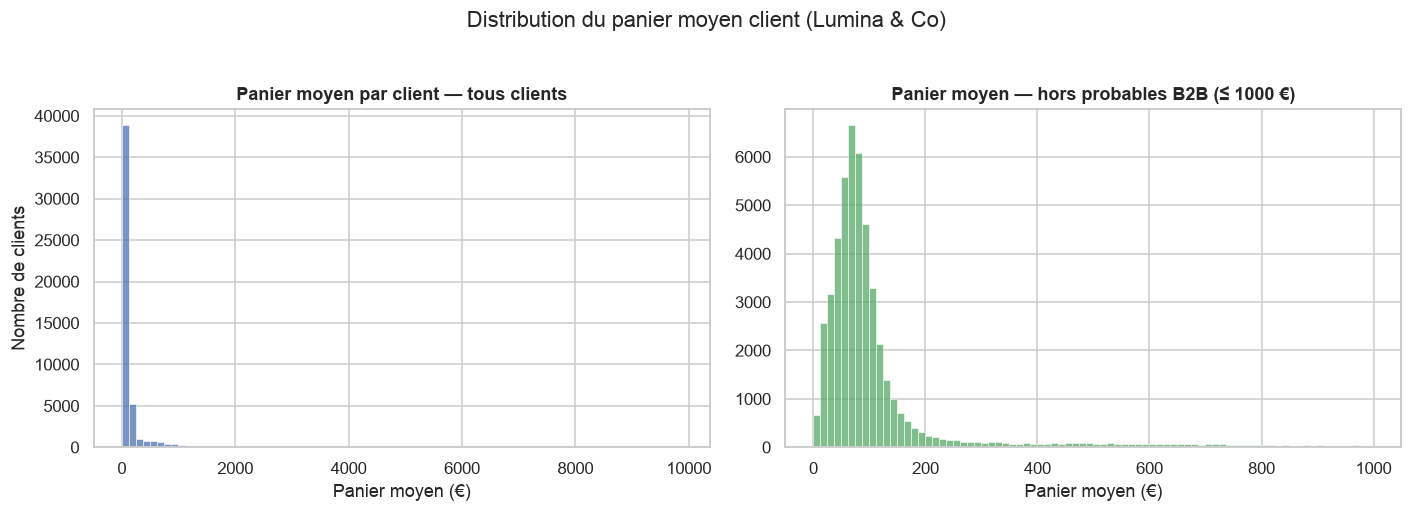

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(customer_metrics["avg_basket"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Panier moyen par client — tous clients")
axes[0].set_xlabel("Panier moyen (€)")
axes[0].set_ylabel("Nombre de clients")

b2c = customer_metrics[customer_metrics["avg_basket"] <= b2b_threshold]
sns.histplot(b2c["avg_basket"], bins=80, ax=axes[1], color="#55A868")
axes[1].set_title(f"Panier moyen — hors probables B2B (≤ {b2b_threshold} €)")
axes[1].set_xlabel("Panier moyen (€)")
axes[1].set_ylabel("")

fig.suptitle("Distribution du panier moyen client (Lumina & Co)", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / "01_distribution_panier_moyen.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** sans filtrage, la distribution est écrasée par une longue queue
qui va jusqu'à plusieurs milliers d'euros de panier moyen. Une fois les
probables comptes B2B mis de côté, la masse des clients grand public se
concentre sur des paniers moyens beaucoup plus resserrés, cohérents avec du
DTC cosmétique.

### Distribution de la fréquence d'achat par client

In [19]:
print(customer_metrics["frequency"].describe().round(2))

count   49,213.00
mean         4.38
std          5.75
min          1.00
25%          1.00
50%          3.00
75%          6.00
max        373.00
Name: frequency, dtype: float64


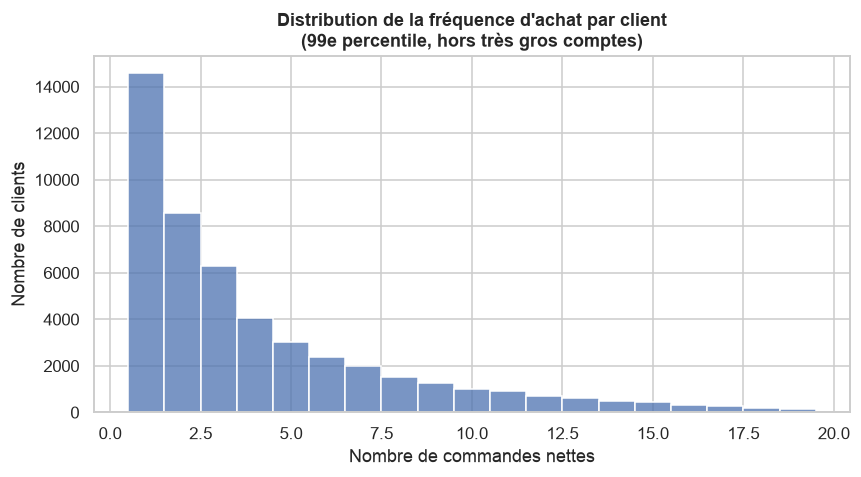

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
max_freq_display = customer_metrics["frequency"].quantile(0.99)
sns.histplot(
    customer_metrics.loc[customer_metrics["frequency"] <= max_freq_display, "frequency"],
    bins=int(max_freq_display), discrete=True, ax=ax, color="#4C72B0",
)
ax.set_title("Distribution de la fréquence d'achat par client\n(99e percentile, hors très gros comptes)")
ax.set_xlabel("Nombre de commandes nettes")
ax.set_ylabel("Nombre de clients")
fig.tight_layout()
fig.savefig(FIGURES / "02_distribution_frequence.png", dpi=150, bbox_inches="tight")
plt.show()

### Courbe de Pareto : quelle part des clients génère 80 % du chiffre d'affaires ?

In [21]:
sorted_rev = customer_metrics["monetary"].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_rev.cumsum() / sorted_rev.sum()
client_share = (sorted_rev.index + 1) / len(sorted_rev)

n80 = (cum_share < 0.8).sum() + 1
pct80 = n80 / len(sorted_rev)
print(f"{n80:,} clients ({pct80:.1%} de la base) génèrent 80 % du chiffre d'affaires net.")

11,199 clients (22.8% de la base) génèrent 80 % du chiffre d'affaires net.


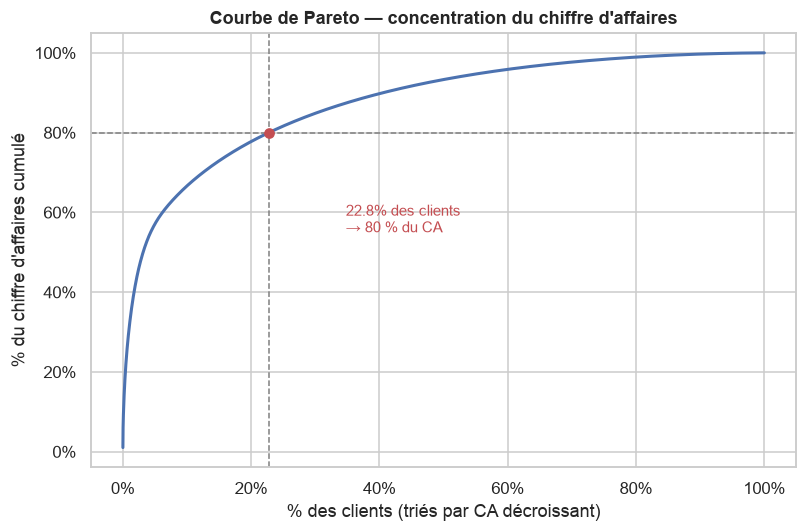

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(client_share * 100, cum_share * 100, color="#4C72B0", linewidth=2)
ax.axhline(80, color="grey", linestyle="--", linewidth=1)
ax.axvline(pct80 * 100, color="grey", linestyle="--", linewidth=1)
ax.scatter([pct80 * 100], [80], color="#C44E52", zorder=5)
ax.annotate(f"{pct80:.1%} des clients\n→ 80 % du CA", xy=(pct80 * 100, 80),
            xytext=(pct80 * 100 + 12, 55), fontsize=10, color="#C44E52")
ax.set_xlabel("% des clients (triés par CA décroissant)")
ax.set_ylabel("% du chiffre d'affaires cumulé")
ax.set_title("Courbe de Pareto — concentration du chiffre d'affaires")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
fig.savefig(FIGURES / "03_courbe_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** la base est concentrée, un peu plus que la règle 80/20
classique — une minorité de clients porte l'essentiel du chiffre d'affaires.
Ce sera un candidat naturel de segment "VIP" en Jour 2.

### Saisonnalité : chiffre d'affaires mensuel sur toute la période

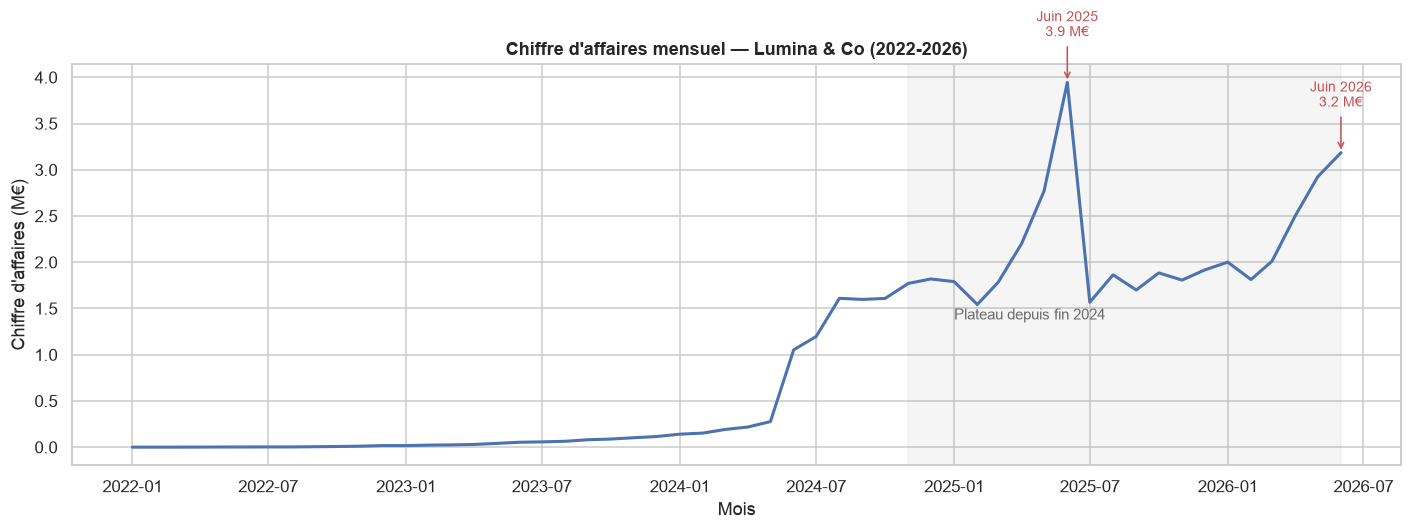

In [23]:
monthly_revenue = (
    sales_all.set_index("invoice_date")["line_total"]
    .resample("MS")
    .sum()
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_revenue.index, monthly_revenue.values / 1e6, color="#4C72B0", linewidth=2)
ax.set_title("Chiffre d'affaires mensuel — Lumina & Co (2022-2026)")
ax.set_xlabel("Mois")
ax.set_ylabel("Chiffre d'affaires (M€)")
ax.axvspan(pd.Timestamp("2024-11-01"), monthly_revenue.index.max(), color="grey", alpha=0.08)
ax.text(pd.Timestamp("2025-01-01"), monthly_revenue.max() / 1e6 * 0.35,
        "Plateau depuis fin 2024", fontsize=10, color="dimgrey")

for year in [2025, 2026]:
    june = pd.Timestamp(f"{year}-06-01")
    if june in monthly_revenue.index:
        ax.annotate(f"Juin {year}\n{monthly_revenue[june]/1e6:.1f} M€",
                    xy=(june, monthly_revenue[june] / 1e6),
                    xytext=(june, monthly_revenue[june] / 1e6 + 0.5),
                    ha="center", fontsize=9, color="#C44E52",
                    arrowprops=dict(arrowstyle="->", color="#C44E52"))

fig.tight_layout()
fig.savefig(FIGURES / "04_ca_mensuel.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** forte croissance de 2022 à fin 2024, puis un plateau net autour
de 1,8 M€/mois de CA net. Le motif se répète chaque année en juin, où le CA
bondit nettement au-dessus du plateau (pic nettement visible en juin 2025 et
juin 2026) — cohérent avec une opération commerciale récurrente (soldes
d'été ?) plutôt qu'un simple bruit statistique. **La stagnation évoquée par le
CMO est donc réelle et visible dans les données**, pas une impression.
Implication marketing : la croissance ne peut plus venir d'un effet de base
qui grossit organiquement — il faut soit élargir la base, soit augmenter la
valeur par client existant (d'où l'intérêt de la segmentation du Jour 2).

### Géographie : répartition des clients et comportements d'achat par pays

In [24]:
country_counts = customers["country"].value_counts()
top_countries = country_counts.head(10)
print(top_countries)
print(f"\nPart de la France : {country_counts['France'] / len(customers):.1%}")

country
France            45904
Germany             918
United Kingdom      760
Spain               291
Portugal            211
Belgium             203
Switzerland         184
Sweden              171
Netherlands         166
Italy               136
Name: count, dtype: int64

Part de la France : 91.3%


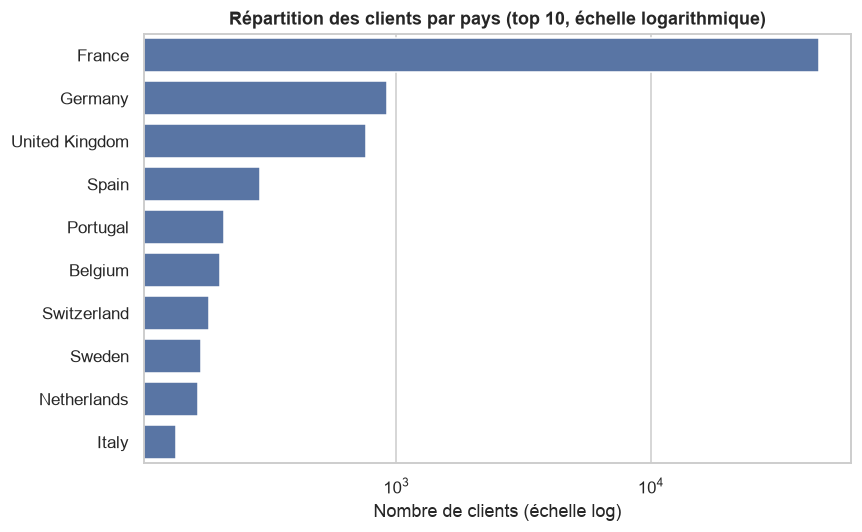

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Nombre de clients (échelle log)")
ax.set_ylabel("")
ax.set_title("Répartition des clients par pays (top 10, échelle logarithmique)")
fig.tight_layout()
fig.savefig(FIGURES / "05_repartition_pays.png", dpi=150, bbox_inches="tight")
plt.show()

> **Point de vigilance :** la France représente 91,3 % de la base. Tous les
> segments RFM du Jour 2 seront donc, de fait, des segments de clients
> français. Les comportements des autres pays existent dans les données mais
> reposent sur des effectifs trop faibles (quelques centaines de clients) pour
> être généralisés — c'est une limite à mentionner explicitement dans la
> présentation finale.

In [26]:
country_metrics = (
    customers[["customer_id", "country"]]
    .merge(customer_metrics, on="customer_id", how="inner")
)
behavior_by_country = (
    country_metrics[country_metrics["country"].isin(top_countries.head(6).index)]
    .groupby("country")
    .agg(n_clients=("customer_id", "count"), panier_moyen=("avg_basket", "mean"), frequence_moyenne=("frequency", "mean"))
    .round(1)
    .sort_values("n_clients", ascending=False)
)
behavior_by_country

,n_clients,panier_moyen,frequence_moyenne
country,,,
France,44919,153.40,4.40
Germany,905,166.30,4.80
United Kingdom,742,156.90,4.60
Spain,283,163.80,3.30
Portugal,206,164.40,3.50
Belgium,200,157.60,5.30


**Lecture :** au-delà des volumes, les comportements (panier moyen,
fréquence) restent globalement du même ordre de grandeur d'un pays à
l'autre — il n'y a pas de marché étranger qui se démarque nettement, ce qui
renforce l'idée que le potentiel de croissance est surtout à chercher dans la
base française existante.

### Répartition du chiffre d'affaires par catégorie

In [27]:
category_revenue = (
    sales_all.groupby("category")["line_total"].sum().sort_values(ascending=False)
)
category_share = (category_revenue / category_revenue.sum() * 100).round(1)
print(category_share)

category
Visage       32.00
Corps        20.80
Coffret      20.60
Cheveux      11.40
Accessoire    8.10
Bain          7.10
Name: line_total, dtype: float64


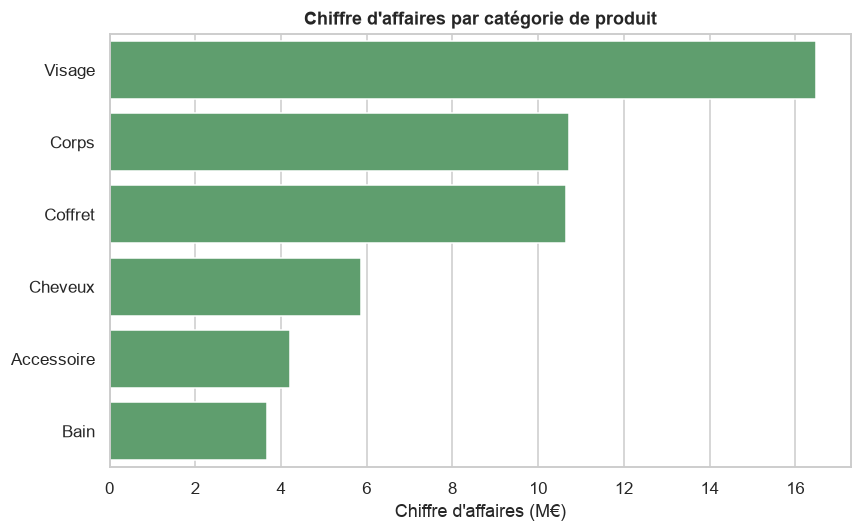

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=category_revenue.values / 1e6, y=category_revenue.index, ax=ax, color="#55A868")
ax.set_xlabel("Chiffre d'affaires (M€)")
ax.set_ylabel("")
ax.set_title("Chiffre d'affaires par catégorie de produit")
fig.tight_layout()
fig.savefig(FIGURES / "06_ca_par_categorie.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** "Visage" domine largement (environ un tiers du CA), suivi de
"Corps" et "Coffret" à des niveaux proches. "Bain" et "Accessoire" sont les
catégories les plus modestes. Cette répartition servira de point de
comparaison au Jour 2 pour voir si certains segments RFM ont une affinité
produit particulière.

### Relations entre variables : récence, fréquence, montant

In [29]:
corr_recency_monetary = customer_metrics[["recency_days", "monetary"]].corr().iloc[0, 1]
corr_freq_basket = customer_metrics[["frequency", "avg_basket"]].corr().iloc[0, 1]
print(f"Corrélation récence / montant dépensé : {corr_recency_monetary:.2f}")
print(f"Corrélation fréquence / panier moyen   : {corr_freq_basket:.2f}")

Corrélation récence / montant dépensé : -0.12
Corrélation fréquence / panier moyen   : 0.08


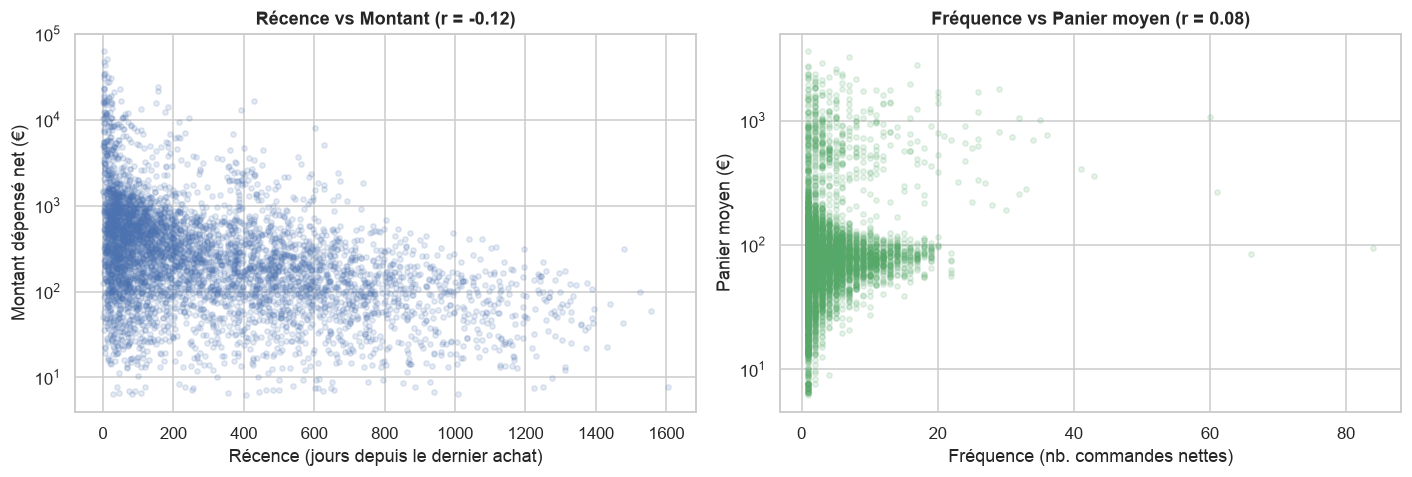

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sample = customer_metrics.sample(min(5000, len(customer_metrics)), random_state=42)
axes[0].scatter(sample["recency_days"], sample["monetary"], alpha=0.15, s=12, color="#4C72B0")
axes[0].set_xlabel("Récence (jours depuis le dernier achat)")
axes[0].set_ylabel("Montant dépensé net (€)")
axes[0].set_yscale("log")
axes[0].set_title(f"Récence vs Montant (r = {corr_recency_monetary:.2f})")

axes[1].scatter(sample["frequency"], sample["avg_basket"], alpha=0.15, s=12, color="#55A868")
axes[1].set_xlabel("Fréquence (nb. commandes nettes)")
axes[1].set_ylabel("Panier moyen (€)")
axes[1].set_yscale("log")
axes[1].set_title(f"Fréquence vs Panier moyen (r = {corr_freq_basket:.2f})")

fig.tight_layout()
fig.savefig(FIGURES / "07_correlations_rfm.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** les deux relations sont faibles et clairement non linéaires
(corrélations proches de 0). Récence et montant ne sont pas de simples
substituts l'un de l'autre, et les clients fréquents ne dépensent pas
mécaniquement plus par commande. C'est un argument fort en faveur d'un RFM à
trois dimensions distinctes au Jour 2 plutôt qu'un score unique : Récence,
Fréquence et Montant capturent chacun une information différente.

### Données zero-party : taux de remplissage et lien avec la valeur client

In [31]:
zero_party_cols = ["declared_preference", "age_bracket", "life_stage", "urban_density"]
fill_rates = (customers[zero_party_cols].notna().mean() * 100).round(1)
print(fill_rates)

declared_preference   38.10
age_bracket           42.70
life_stage            22.50
urban_density         19.80
dtype: float64


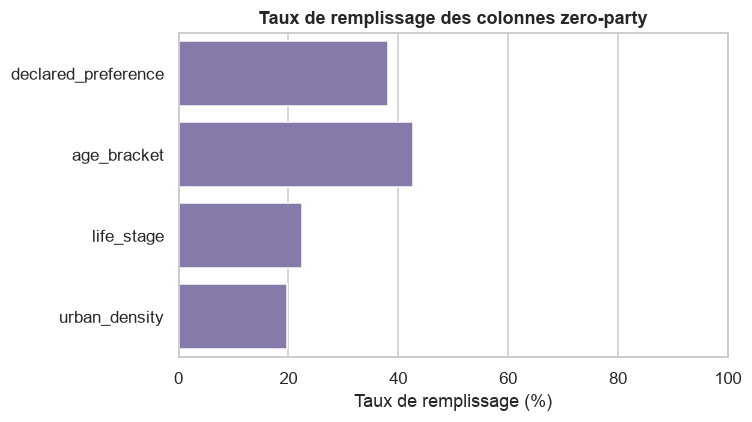

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=fill_rates.values, y=fill_rates.index, ax=ax, color="#8172B2")
ax.set_xlabel("Taux de remplissage (%)")
ax.set_ylabel("")
ax.set_title("Taux de remplissage des colonnes zero-party")
ax.set_xlim(0, 100)
fig.tight_layout()
fig.savefig(FIGURES / "08_remplissage_zero_party.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
customers_with_metrics = customers.merge(customer_metrics[["customer_id", "monetary", "frequency"]], on="customer_id", how="left")

rows = []
for col in zero_party_cols:
    filled = customers_with_metrics[col].notna()
    rows.append({
        "colonne": col,
        "taux_remplissage_%": fill_rates[col],
        "monetary_moyen_rempli": customers_with_metrics.loc[filled, "monetary"].mean(),
        "monetary_moyen_non_rempli": customers_with_metrics.loc[~filled, "monetary"].mean(),
    })
zero_party_vs_value = pd.DataFrame(rows).round(1)
zero_party_vs_value

,colonne,taux_remplissage_%,monetary_moyen_rempli,monetary_moyen_non_rempli
0,declared_preference,38.10,819.40,808.50
1,age_bracket,42.70,791.60,828.30
2,life_stage,22.50,787.80,819.80
3,urban_density,19.80,795.90,816.80


**Lecture :** le remplissage est faible (19,8 % à 42,7 % selon la colonne),
ce qui est attendu pour de la donnée zero-party (déclarative, non
obligatoire). Mais surtout, le montant dépensé moyen est quasiment identique
entre les clients qui ont renseigné une information et ceux qui ne l'ont pas
fait. **Déclarer ses préférences n'est donc pas un signal d'engagement ou de
valeur** — probablement plus lié au canal ou au moment d'acquisition qu'au
comportement d'achat.

## Étape 5 — Hypothèses marketing

Ces hypothèses seront testées via la segmentation RFM au Jour 2.

**1.** Je suppose que la stagnation du chiffre d'affaires autour de 1,8 M€/mois
depuis fin 2024 implique que la croissance ne vient plus de l'élargissement
naturel de la base, ce qui suggère de prioriser des actions sur la valeur des
clients existants (montée en fréquence ou en panier) plutôt que la seule
acquisition.

**2.** Je suppose que la forte concentration du chiffre d'affaires (22,8 %
des clients génèrent 80 % du CA net) implique l'existence d'un segment à très
forte valeur nettement minoritaire, ce qui suggère de créer un segment VIP
dédié avec un traitement CRM différencié (et non le même email que les 77 %
restants) dès le Jour 2.

**3.** Je suppose que le pic récurrent de juin (chaque année, nettement
au-dessus du plateau mensuel) implique un événement commercial saisonnier
prévisible, ce qui suggère de concentrer une partie du budget d'acquisition
et de relance CRM sur cette période plutôt que de le lisser uniformément sur
l'année.

**4.** Je suppose que l'absence de corrélation entre récence et montant
dépensé (r ≈ 0) implique que les gros clients ne sont pas nécessairement les
plus récents, ce qui suggère qu'un score RFM à trois dimensions distinctes est
nécessaire — un score composite unique masquerait des profils "gros client
mais qui décroche" invisibles autrement.

**5.** Je suppose que le fait que 91,3 % des clients soient français, combiné
à un remplissage zero-party non corrélé à la valeur, implique que la
segmentation du Jour 2 doit s'appuyer avant tout sur le comportement transactionnel
(RFM) plutôt que sur la géographie ou les données déclaratives, ce qui suggère
de traiter ces dernières comme des axes d'enrichissement secondaires et non
comme critères de segmentation primaires.